# Lab Problem Statement 6: Statistical Analysis of Physical Characteristics of Palmer Penguins


## Setup: Install & Load Packages

In [1]:
# Install required packages (only needed once per session)
packages <- c("palmerpenguins", "dplyr", "ggplot2", "moments", "car", "tidyr")
new_packages <- packages[!(packages %in% installed.packages()[,"Package"])]
if(length(new_packages)) install.packages(new_packages, repos = "https://cloud.r-project.org")

library(palmerpenguins)
library(dplyr)
library(ggplot2)
library(moments)
library(car)
library(tidyr)

set.seed(42)

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘colorspace’, ‘fracdiff’, ‘lmtest’, ‘timeDate’, ‘urca’, ‘zoo’, ‘RcppArmadillo’, ‘cowplot’, ‘Deriv’, ‘forecast’, ‘rbibutils’, ‘numDeriv’, ‘doBy’, ‘SparseM’, ‘MatrixModels’, ‘Rdpack’, ‘minqa’, ‘nloptr’, ‘reformulas’, ‘RcppEigen’, ‘carData’, ‘abind’, ‘Formula’, ‘pbkrtest’, ‘quantreg’, ‘lme4’



Attaching package: ‘palmerpenguins’


The following objects are masked from ‘package:datasets’:

    penguins, penguins_raw



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: carData


Attaching package: ‘car’


The following object is masked from ‘package:dplyr’:

    recode




## 1. Load & Clean the Dataset

In [2]:
data("penguins")
penguins <- as.data.frame(penguins)

# Basic structure
str(penguins)
summary(penguins)

# Remove rows with missing values in key variables
penguins_clean <- penguins %>%
  filter(!is.na(body_mass_g), !is.na(flipper_length_mm), !is.na(sex))

cat("Original rows:", nrow(penguins), "\n")
cat("Clean rows:", nrow(penguins_clean), "\n")

head(penguins_clean)


'data.frame':	344 obs. of  8 variables:
 $ species          : Factor w/ 3 levels "Adelie","Chinstrap",..: 1 1 1 1 1 1 1 1 1 1 ...
 $ island           : Factor w/ 3 levels "Biscoe","Dream",..: 3 3 3 3 3 3 3 3 3 3 ...
 $ bill_length_mm   : num  39.1 39.5 40.3 NA 36.7 39.3 38.9 39.2 34.1 42 ...
 $ bill_depth_mm    : num  18.7 17.4 18 NA 19.3 20.6 17.8 19.6 18.1 20.2 ...
 $ flipper_length_mm: int  181 186 195 NA 193 190 181 195 193 190 ...
 $ body_mass_g      : int  3750 3800 3250 NA 3450 3650 3625 4675 3475 4250 ...
 $ sex              : Factor w/ 2 levels "female","male": 2 1 1 NA 1 2 1 2 NA NA ...
 $ year             : int  2007 2007 2007 2007 2007 2007 2007 2007 2007 2007 ...


      species          island    bill_length_mm  bill_depth_mm  
 Adelie   :152   Biscoe   :168   Min.   :32.10   Min.   :13.10  
 Chinstrap: 68   Dream    :124   1st Qu.:39.23   1st Qu.:15.60  
 Gentoo   :124   Torgersen: 52   Median :44.45   Median :17.30  
                                 Mean   :43.92   Mean   :17.15  
                                 3rd Qu.:48.50   3rd Qu.:18.70  
                                 Max.   :59.60   Max.   :21.50  
                                 NAs    :2       NAs    :2      
 flipper_length_mm  body_mass_g       sex           year     
 Min.   :172.0     Min.   :2700   female:165   Min.   :2007  
 1st Qu.:190.0     1st Qu.:3550   male  :168   1st Qu.:2007  
 Median :197.0     Median :4050   NAs   : 11   Median :2008  
 Mean   :200.9     Mean   :4202                Mean   :2008  
 3rd Qu.:213.0     3rd Qu.:4750                3rd Qu.:2009  
 Max.   :231.0     Max.   :6300                Max.   :2009  
 NAs    :2         NAs    :2                  

Original rows: 344 
Clean rows: 333 


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
,<fct>,<fct>,<dbl>,<dbl>,<int>,<int>,<fct>,<int>
1,Adelie,Torgersen,39.1,18.7,181,3750,male,2007
2,Adelie,Torgersen,39.5,17.4,186,3800,female,2007
3,Adelie,Torgersen,40.3,18.0,195,3250,female,2007
4,Adelie,Torgersen,36.7,19.3,193,3450,female,2007
5,Adelie,Torgersen,39.3,20.6,190,3650,male,2007
6,Adelie,Torgersen,38.9,17.8,181,3625,female,2007


## 2. Descriptive Statistical Analysis

Compute mean, median, min, max, variance, SD, quartiles, IQR, skewness, and kurtosis for `body_mass_g`, overall and by species.

In [3]:
describe_var <- function(x) {
  c(
    Mean     = mean(x, na.rm = TRUE),
    Median   = median(x, na.rm = TRUE),
    Min      = min(x, na.rm = TRUE),
    Max      = max(x, na.rm = TRUE),
    Variance = var(x, na.rm = TRUE),
    SD       = sd(x, na.rm = TRUE),
    Q1       = quantile(x, 0.25, na.rm = TRUE),
    Q3       = quantile(x, 0.75, na.rm = TRUE),
    IQR      = IQR(x, na.rm = TRUE),
    Skewness = skewness(x, na.rm = TRUE),
    Kurtosis = kurtosis(x, na.rm = TRUE)
  )
}

# Overall descriptive statistics for body mass
overall_stats <- describe_var(penguins_clean$body_mass_g)
cat("---- Overall Body Mass Statistics ----\n")
print(round(overall_stats, 2))

# Descriptive statistics by species
species_stats <- penguins_clean %>%
  group_by(species) %>%
  summarise(
    Mean     = mean(body_mass_g),
    Median   = median(body_mass_g),
    Min      = min(body_mass_g),
    Max      = max(body_mass_g),
    Variance = var(body_mass_g),
    SD       = sd(body_mass_g),
    Q1       = quantile(body_mass_g, 0.25),
    Q3       = quantile(body_mass_g, 0.75),
    IQR      = IQR(body_mass_g),
    Skewness = skewness(body_mass_g),
    Kurtosis = kurtosis(body_mass_g)
  )

cat("\n---- Body Mass Statistics by Species ----\n")
print(as.data.frame(species_stats))

---- Overall Body Mass Statistics ----
     Mean    Median       Min       Max  Variance        SD    Q1.25%    Q3.75% 
  4207.06   4050.00   2700.00   6300.00 648372.49    805.22   3550.00   4775.00 
      IQR  Skewness  Kurtosis 
  1225.00      0.47      2.26 

---- Body Mass Statistics by Species ----
    species     Mean Median  Min  Max Variance       SD     Q1   Q3   IQR
1    Adelie 3706.164   3700 2850 4775 210332.4 458.6201 3362.5 4000 637.5
2 Chinstrap 3733.088   3700 2700 4800 147713.5 384.3351 3487.5 3950 462.5
3    Gentoo 5092.437   5050 3950 6300 251478.3 501.4762 4700.0 5500 800.0
   Skewness Kurtosis
1 0.2770077 2.411479
2 0.2419413 3.463681
3 0.0449965 2.242850


### 2.1 Visualizations: Histogram, Boxplot, Density Plot

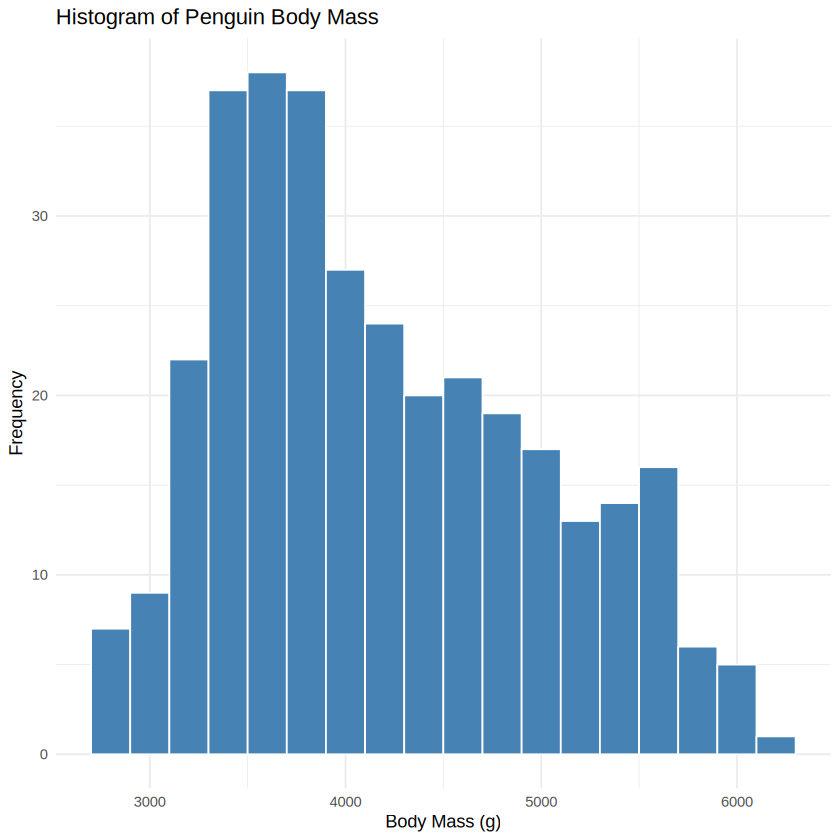

In [4]:
# Histogram of body mass
ggplot(penguins_clean, aes(x = body_mass_g)) +
  geom_histogram(binwidth = 200, fill = "steelblue", color = "white") +
  labs(title = "Histogram of Penguin Body Mass",
       x = "Body Mass (g)", y = "Frequency") +
  theme_minimal()

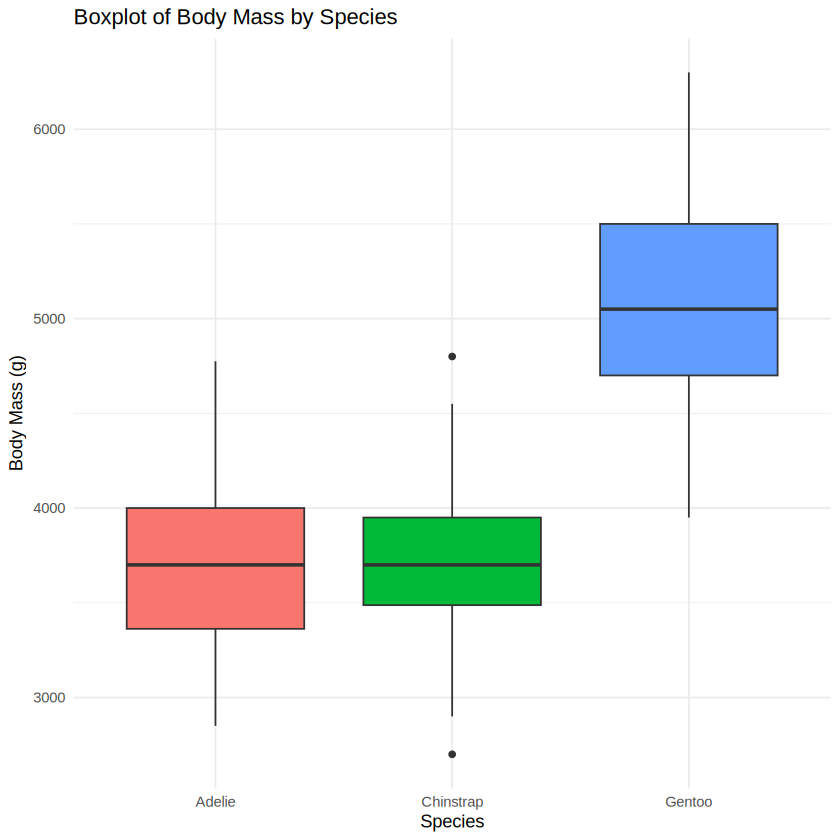

In [5]:
# Boxplot of body mass by species
ggplot(penguins_clean, aes(x = species, y = body_mass_g, fill = species)) +
  geom_boxplot() +
  labs(title = "Boxplot of Body Mass by Species",
       x = "Species", y = "Body Mass (g)") +
  theme_minimal() +
  theme(legend.position = "none")

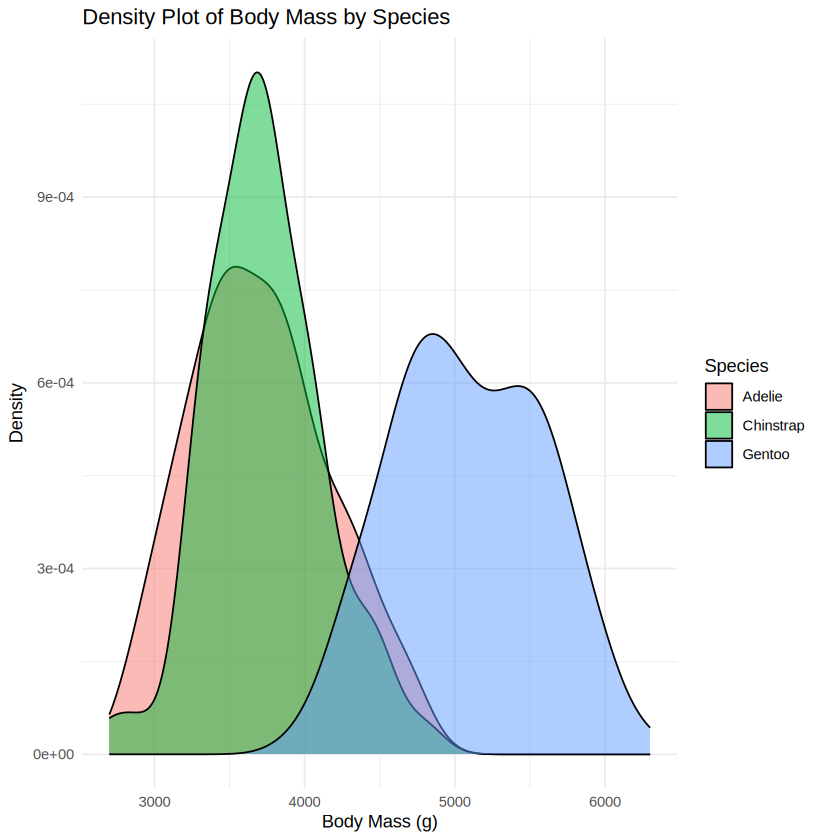

In [6]:
# Density plot of body mass by species
ggplot(penguins_clean, aes(x = body_mass_g, fill = species)) +
  geom_density(alpha = 0.5) +
  labs(title = "Density Plot of Body Mass by Species",
       x = "Body Mass (g)", y = "Density", fill = "Species") +
  theme_minimal()

## 3. Hypothesis Testing: Male vs Female Body Mass

**H0:** There is no significant difference in mean body mass between male and female penguins (μ_male = μ_female)

**H1:** There is a significant difference in mean body mass between male and female penguins (μ_male ≠ μ_female)

In [7]:
male_mass   <- penguins_clean$body_mass_g[penguins_clean$sex == "male"]
female_mass <- penguins_clean$body_mass_g[penguins_clean$sex == "female"]

# 3.1 Normality check: Shapiro-Wilk test
cat("Shapiro-Wilk test (Male):\n")
print(shapiro.test(male_mass))

cat("\nShapiro-Wilk test (Female):\n")
print(shapiro.test(female_mass))

Shapiro-Wilk test (Male):

	Shapiro-Wilk normality test

data:  male_mass
W = 0.92504, p-value = 1.227e-07


Shapiro-Wilk test (Female):

	Shapiro-Wilk normality test

data:  female_mass
W = 0.91931, p-value = 6.155e-08



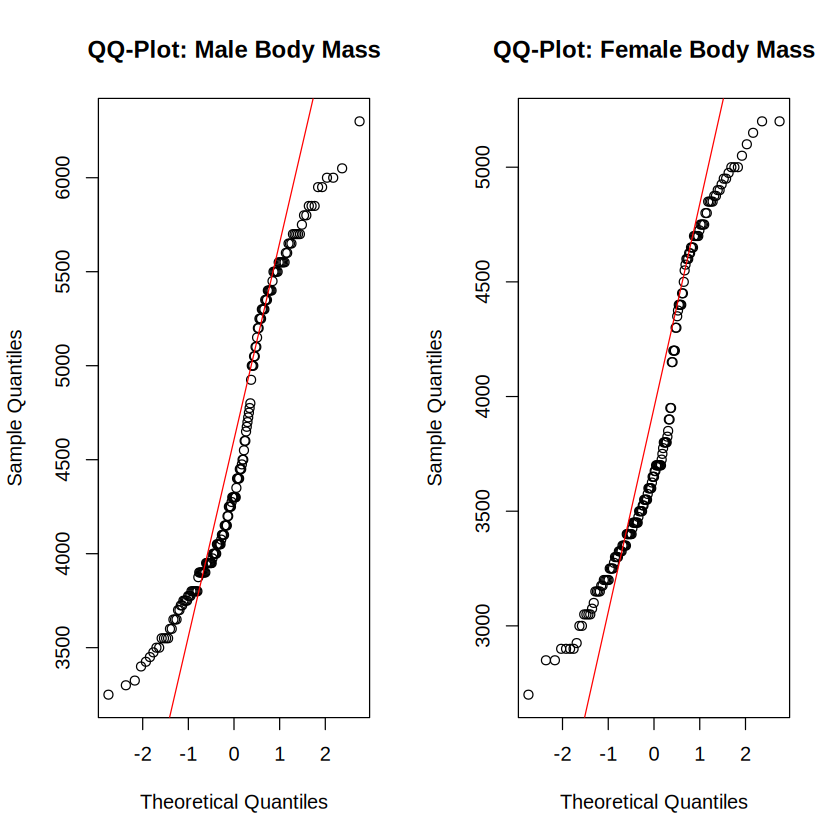

In [8]:
# 3.2 QQ-plots for normality
par(mfrow = c(1, 2))
qqnorm(male_mass, main = "QQ-Plot: Male Body Mass"); qqline(male_mass, col = "red")
qqnorm(female_mass, main = "QQ-Plot: Female Body Mass"); qqline(female_mass, col = "red")
par(mfrow = c(1, 1))

In [9]:
# 3.3 Independent two-sample t-test (Welch's by default; robust to unequal variances)
t_test_result <- t.test(body_mass_g ~ sex, data = penguins_clean)
print(t_test_result)


	Welch Two Sample t-test

data:  body_mass_g by sex
t = -8.5545, df = 323.9, p-value = 4.794e-16
alternative hypothesis: true difference in means between group female and group male is not equal to 0
95 percent confidence interval:
 -840.5783 -526.2453
sample estimates:
mean in group female   mean in group male 
            3862.273             4545.685 



In [10]:
# 3.4 95% Confidence Interval for the difference between mean body masses
cat("95% CI for difference in means (Female - Male):\n")
print(t_test_result$conf.int)

95% CI for difference in means (Female - Male):
[1] -840.5783 -526.2453
attr(,"conf.level")
[1] 0.95


In [11]:
# 3.5 Effect size: Cohen's d
cohens_d <- function(x, y) {
  nx <- length(x); ny <- length(y)
  pooled_sd <- sqrt(((nx - 1) * var(x) + (ny - 1) * var(y)) / (nx + ny - 2))
  (mean(x) - mean(y)) / pooled_sd
}

d_value <- cohens_d(male_mass, female_mass)
cat("Cohen's d:", round(d_value, 3), "\n")

# Rule-of-thumb interpretation
interpret_d <- function(d) {
  d <- abs(d)
  if (d < 0.2) "negligible"
  else if (d < 0.5) "small"
  else if (d < 0.8) "medium"
  else "large"
}
cat("Effect size interpretation:", interpret_d(d_value), "\n")

Cohen's d: 0.936 
Effect size interpretation: large 


**3.6 Interpretation:** Report the p-value from the t-test, the 95% CI, and Cohen's d together.
If p < 0.05, we reject H0 and conclude there is a statistically significant difference in mean body mass between sexes. The confidence interval indicates the plausible range for that difference, and Cohen's d indicates the magnitude/practical significance of the effect (independent of sample size).

## 4. One-Way ANOVA: Body Mass Across Species

**H0:** Mean body mass is equal across all three species.

**H1:** At least one species has a different mean body mass.

In [12]:
# 4.1 Distribution within each species (already visualized above); check normality
by(penguins_clean$body_mass_g, penguins_clean$species, shapiro.test)

penguins_clean$species: Adelie

	Shapiro-Wilk normality test

data:  dd[x, ]
W = 0.98116, p-value = 0.04232

------------------------------------------------------------ 
penguins_clean$species: Chinstrap

	Shapiro-Wilk normality test

data:  dd[x, ]
W = 0.98449, p-value = 0.5605

------------------------------------------------------------ 
penguins_clean$species: Gentoo

	Shapiro-Wilk normality test

data:  dd[x, ]
W = 0.98606, p-value = 0.2605


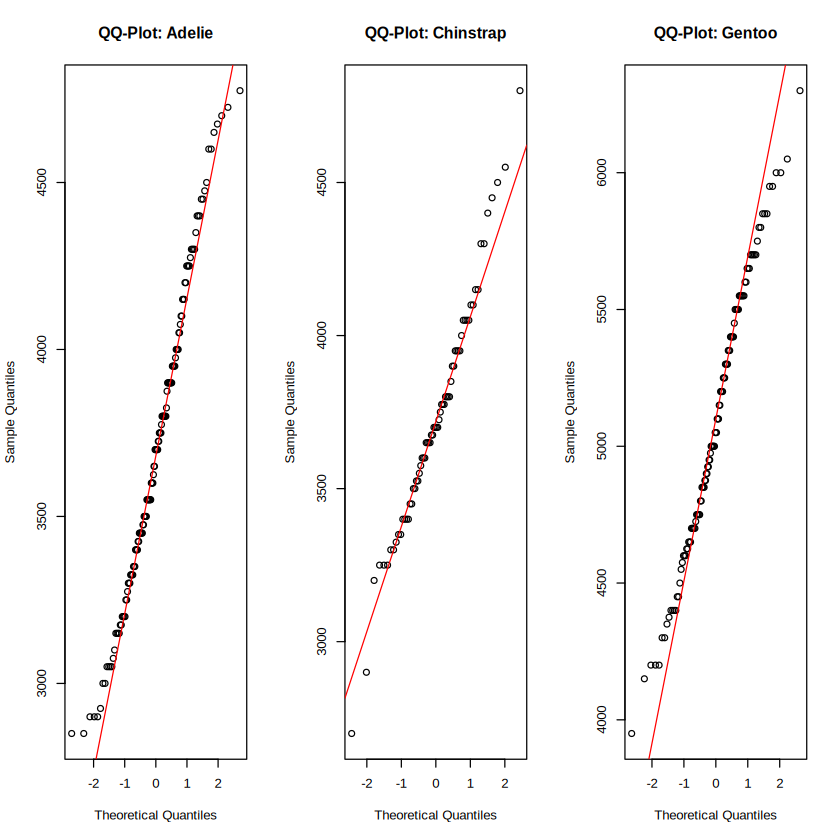

In [13]:
# QQ-plots by species
par(mfrow = c(1, 3))
for (sp in levels(penguins_clean$species)) {
  sub <- penguins_clean$body_mass_g[penguins_clean$species == sp]
  qqnorm(sub, main = paste("QQ-Plot:", sp)); qqline(sub, col = "red")
}
par(mfrow = c(1, 1))

In [14]:
# 4.2 Homogeneity of variance: Levene's test
levene_result <- leveneTest(body_mass_g ~ species, data = penguins_clean)
print(levene_result)

Levene's Test for Homogeneity of Variance (center = median)
       Df F value   Pr(>F)   
group   2  5.1349 0.006367 **
      330                    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


In [15]:
# 4.3 One-way ANOVA
anova_model <- aov(body_mass_g ~ species, data = penguins_clean)
anova_summary <- summary(anova_model)
print(anova_summary)

# Extract key statistics
f_stat  <- anova_summary[[1]]["species", "F value"]
df_between <- anova_summary[[1]]["species", "Df"]
df_within  <- anova_summary[[1]]["Residuals", "Df"]
p_value <- anova_summary[[1]]["species", "Pr(>F)"]

cat("F-statistic:", round(f_stat, 3), "\n")
cat("Degrees of freedom: (", df_between, ",", df_within, ")\n")
cat("p-value:", format.pval(p_value, digits = 4), "\n")

             Df    Sum Sq  Mean Sq F value Pr(>F)    
species       2 145190219 72595110   341.9 <2e-16 ***
Residuals   330  70069447   212332                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1
F-statistic: 341.895 
Degrees of freedom: ( 2 , 330 )
p-value: < 2.2e-16 


  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = body_mass_g ~ species, data = penguins_clean)

$species
                       diff       lwr       upr    p adj
Chinstrap-Adelie   26.92385 -132.3528  186.2005 0.916431
Gentoo-Adelie    1386.27259 1252.2897 1520.2554 0.000000
Gentoo-Chinstrap 1359.34874 1194.4304 1524.2671 0.000000



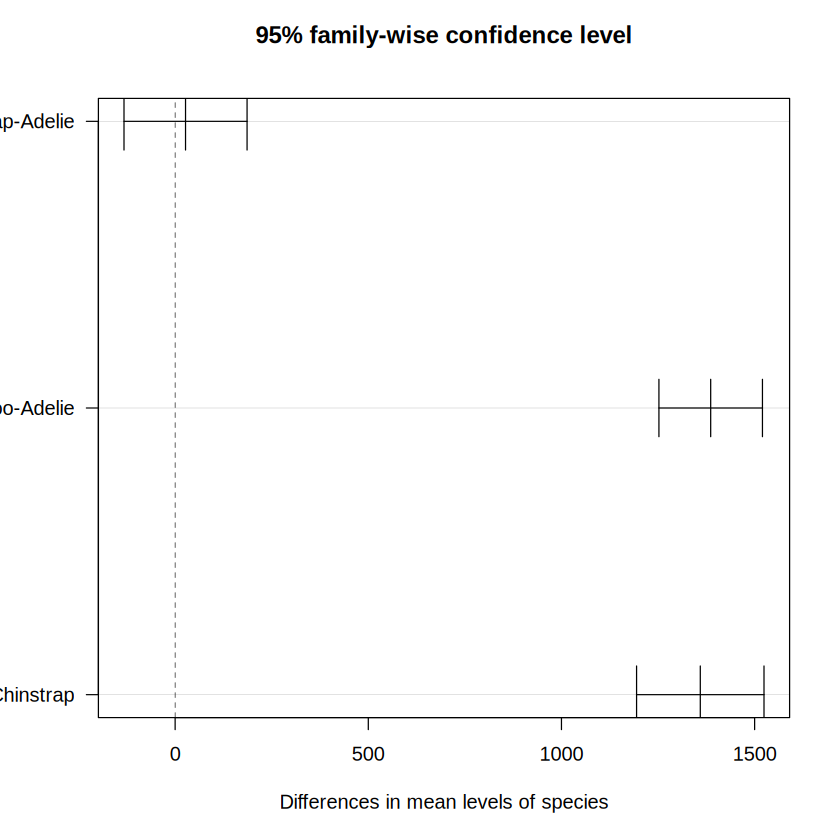

In [16]:
# 4.4 Tukey's HSD post-hoc test (only meaningful if ANOVA is significant)
if (p_value < 0.05) {
  tukey_result <- TukeyHSD(anova_model)
  print(tukey_result)
  plot(tukey_result, las = 1)
} else {
  cat("ANOVA not significant; Tukey's HSD not required.\n")
}

## 5. Non-Parametric Analysis: Kruskal-Wallis Test

Used as a robustness check, especially useful if ANOVA assumptions (normality/homogeneity of variance) are notably violated.

In [17]:
kruskal_result <- kruskal.test(body_mass_g ~ species, data = penguins_clean)
print(kruskal_result)

cat("\n---- Comparison ----\n")
cat("One-way ANOVA p-value:      ", format.pval(p_value, digits = 4), "\n")
cat("Kruskal-Wallis p-value:     ", format.pval(kruskal_result$p.value, digits = 4), "\n")
cat("Both significant at 0.05?  ", (p_value < 0.05) & (kruskal_result$p.value < 0.05), "\n")


	Kruskal-Wallis rank sum test

data:  body_mass_g by species
Kruskal-Wallis chi-squared = 212.09, df = 2, p-value < 2.2e-16


---- Comparison ----
One-way ANOVA p-value:       < 2.2e-16 
Kruskal-Wallis p-value:      < 2.2e-16 
Both significant at 0.05?   TRUE 


**Discussion:** Compare conclusions from the parametric ANOVA and the non-parametric Kruskal-Wallis test. If both tests agree (both significant or both non-significant), this strengthens confidence in the conclusion regardless of the normality assumption violations noted above.

## 6. Two-Way ANOVA: Species × Sex Effect on Body Mass

In [18]:
twoway_model <- aov(body_mass_g ~ species * sex, data = penguins_clean)
twoway_summary <- summary(twoway_model)
print(twoway_summary)

             Df    Sum Sq  Mean Sq F value   Pr(>F)    
species       2 145190219 72595110 758.358  < 2e-16 ***
sex           1  37090262 37090262 387.460  < 2e-16 ***
species:sex   2   1676557   838278   8.757 0.000197 ***
Residuals   327  31302628    95727                     
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


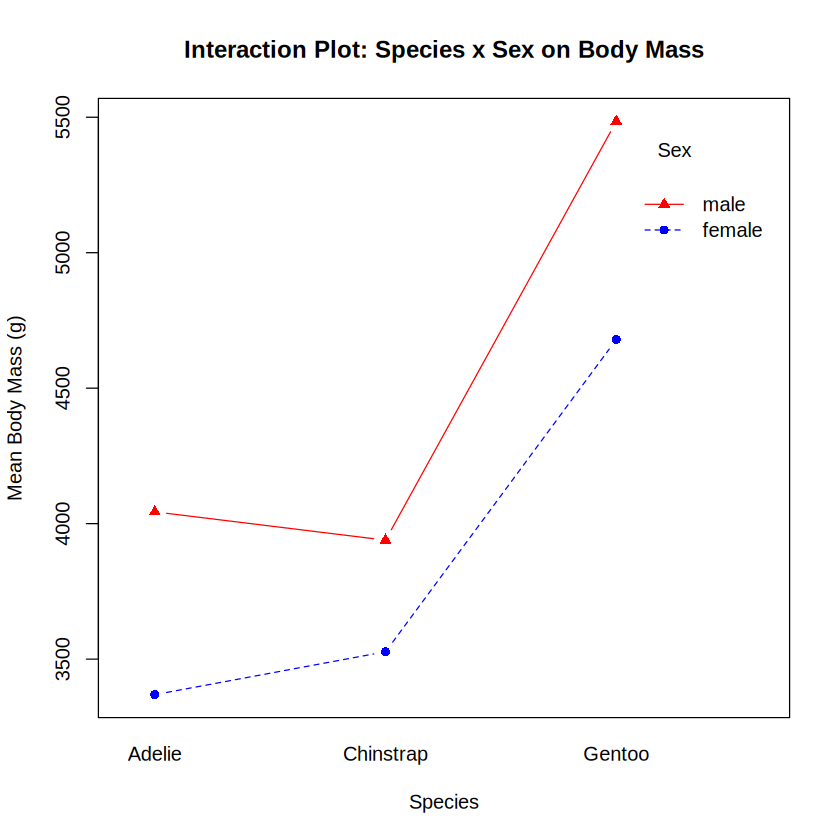

In [19]:
# Interaction plot
interaction.plot(
  x.factor = penguins_clean$species,
  trace.factor = penguins_clean$sex,
  response = penguins_clean$body_mass_g,
  fun = mean,
  type = "b",
  col = c("blue", "red"),
  pch = c(16, 17),
  xlab = "Species",
  ylab = "Mean Body Mass (g)",
  trace.label = "Sex",
  main = "Interaction Plot: Species x Sex on Body Mass"
)

**Interpretation guide:**
- If the `species` p-value < 0.05 → species significantly affects body mass.
- If the `sex` p-value < 0.05 → sex significantly affects body mass.
- If the `species:sex` interaction p-value < 0.05 → the effect of species on body mass depends on sex (and vice versa).

## 7. Additional Analysis: Flipper Length Across Species

In [20]:
# Descriptive stats for flipper length by species
flipper_stats <- penguins_clean %>%
  group_by(species) %>%
  summarise(
    Mean     = mean(flipper_length_mm),
    Median   = median(flipper_length_mm),
    SD       = sd(flipper_length_mm),
    Min      = min(flipper_length_mm),
    Max      = max(flipper_length_mm)
  )
print(as.data.frame(flipper_stats))

    species     Mean Median       SD Min Max
1    Adelie 190.1027    190 6.521825 172 210
2 Chinstrap 195.8235    196 7.131894 178 212
3    Gentoo 217.2353    216 6.585431 203 231


In [21]:
# Normality & variance checks
by(penguins_clean$flipper_length_mm, penguins_clean$species, shapiro.test)
leveneTest(flipper_length_mm ~ species, data = penguins_clean)

penguins_clean$species: Adelie

	Shapiro-Wilk normality test

data:  dd[x, ]
W = 0.9934, p-value = 0.7427

------------------------------------------------------------ 
penguins_clean$species: Chinstrap

	Shapiro-Wilk normality test

data:  dd[x, ]
W = 0.98891, p-value = 0.8106

------------------------------------------------------------ 
penguins_clean$species: Gentoo

	Shapiro-Wilk normality test

data:  dd[x, ]
W = 0.96148, p-value = 0.00176


,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,2,0.4427865,0.6426253
,330,NA,NA


In [22]:
# One-way ANOVA for flipper length
flipper_anova <- aov(flipper_length_mm ~ species, data = penguins_clean)
flipper_summary <- summary(flipper_anova)
print(flipper_summary)

flipper_p <- flipper_summary[[1]]["species", "Pr(>F)"]

if (flipper_p < 0.05) {
  print(TukeyHSD(flipper_anova))
}

# Kruskal-Wallis for flipper length
kruskal.test(flipper_length_mm ~ species, data = penguins_clean)

             Df Sum Sq Mean Sq F value Pr(>F)    
species       2  50526   25263   567.4 <2e-16 ***
Residuals   330  14693      45                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1
  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = flipper_length_mm ~ species, data = penguins_clean)

$species
                     diff       lwr       upr p adj
Chinstrap-Adelie  5.72079  3.414364  8.027215     0
Gentoo-Adelie    27.13255 25.192399 29.072709     0
Gentoo-Chinstrap 21.41176 19.023644 23.799885     0




	Kruskal-Wallis rank sum test

data:  flipper_length_mm by species
Kruskal-Wallis chi-squared = 237.35, df = 2, p-value < 2.2e-16


**Discussion:** Compare the ANOVA/Kruskal-Wallis results for flipper length with those obtained for body mass. Note whether species differences follow the same pattern (e.g., Gentoo penguins tend to be both heavier and have longer flippers), suggesting consistent overall body-size differences among species.

## 8. Additional Visualizations

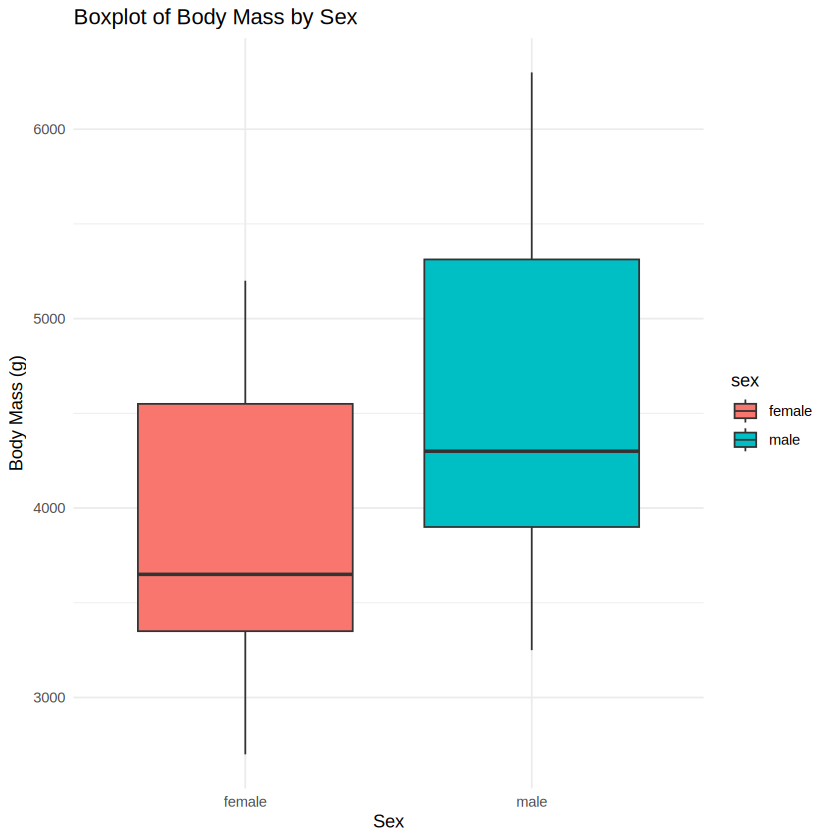

In [23]:
# Sex-wise boxplot of body mass
ggplot(penguins_clean, aes(x = sex, y = body_mass_g, fill = sex)) +
  geom_boxplot() +
  labs(title = "Boxplot of Body Mass by Sex", x = "Sex", y = "Body Mass (g)") +
  theme_minimal()

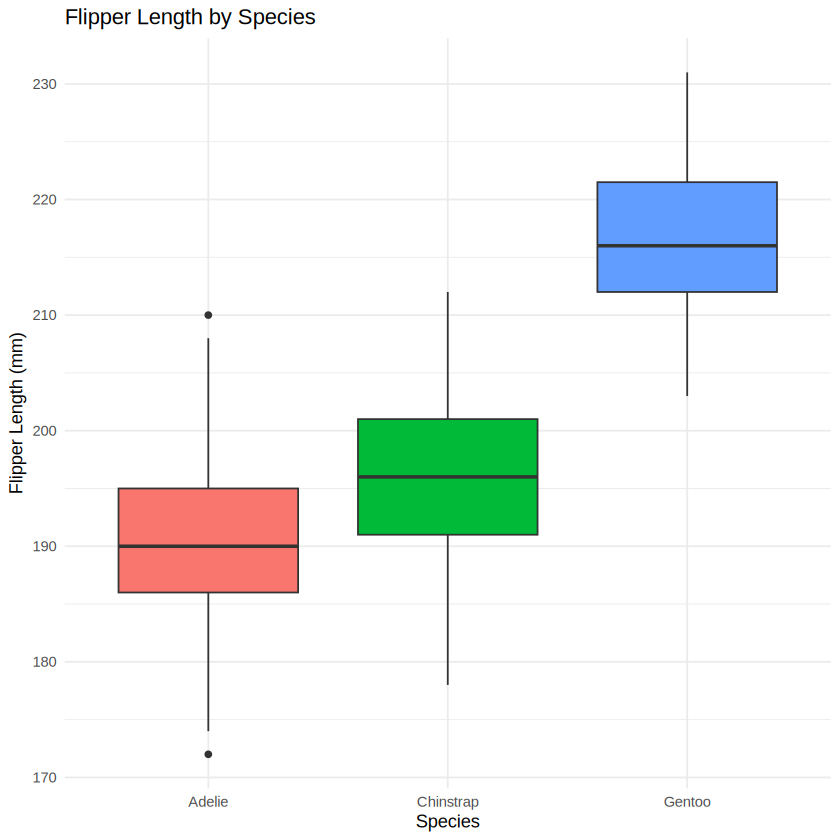

In [24]:
# Species-wise flipper length comparison
ggplot(penguins_clean, aes(x = species, y = flipper_length_mm, fill = species)) +
  geom_boxplot() +
  labs(title = "Flipper Length by Species", x = "Species", y = "Flipper Length (mm)") +
  theme_minimal() +
  theme(legend.position = "none")

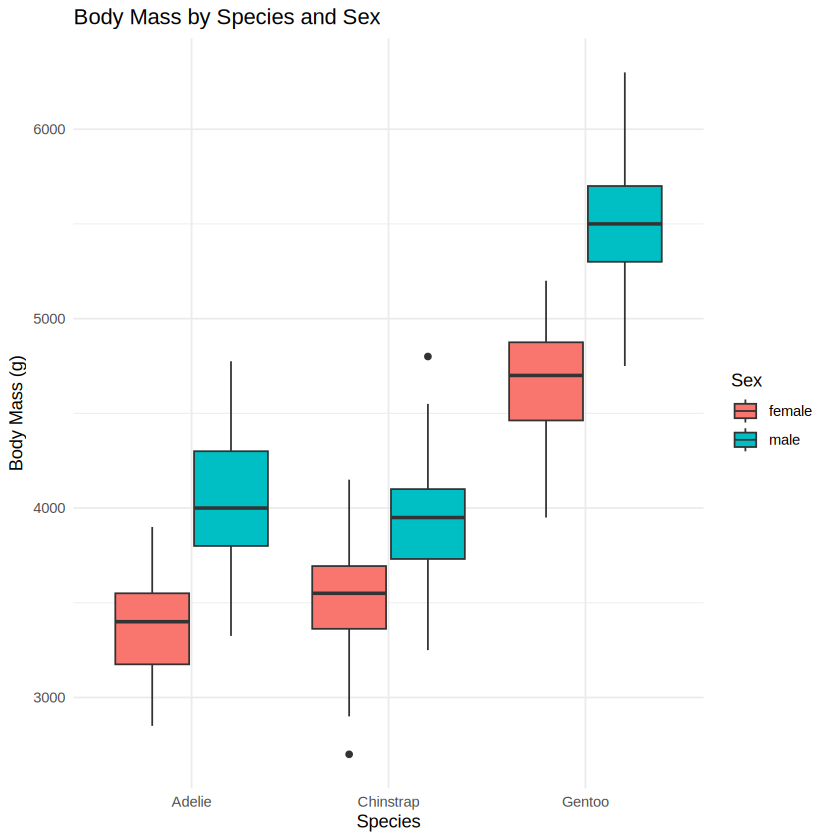

In [25]:
# Group comparison plot (body mass, species x sex) showing significant differences
ggplot(penguins_clean, aes(x = species, y = body_mass_g, fill = sex)) +
  geom_boxplot(position = position_dodge(0.8)) +
  labs(title = "Body Mass by Species and Sex",
       x = "Species", y = "Body Mass (g)", fill = "Sex") +
  theme_minimal()

**Conclusion:** Both body mass and flipper length differ significantly across penguin species (Gentoo penguins are notably larger), and body mass also differs significantly by sex, with males generally heavier than females across species.